In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from scipy.integrate import solve_ivp

# Problem 1

***Part A***

Initiation (t = 1 h)
  X = 29.9066 g/L,  S = 2.7472 g/L,  P = 37.4727 g/L,  V = 1.0500 L
Processing (t = 6 h)
  X = 30.5952 g/L,  S = 8.8181 g/L,  P = 156.0809 g/L,  V = 3.5500 L
Harvesting (t = 7 h)
  X = 34.5634 g/L,  S = 0.0000 g/L,  P = 182.5352 g/L,  V = 1.0500 L


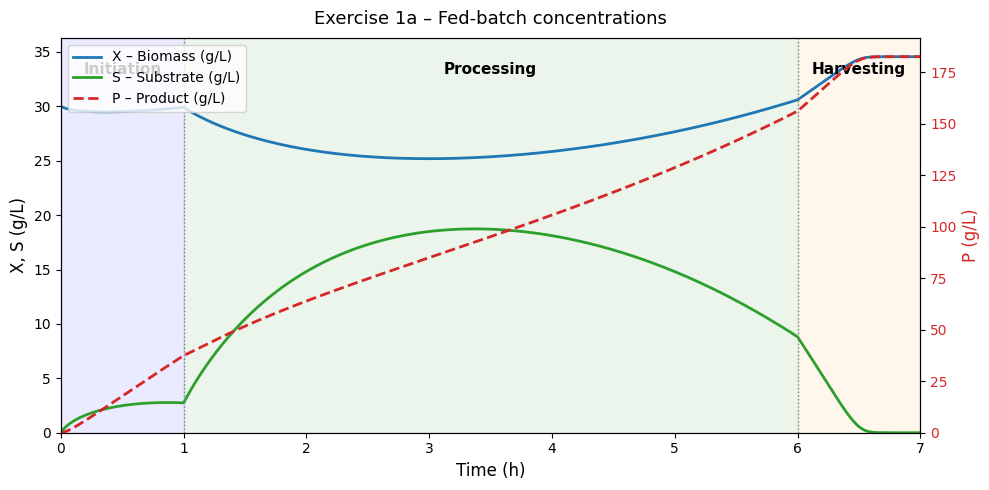

In [3]:
mu_max = 0.3
Ks     = 0.8
Ki     = 100.0
Yxs    = 0.45
Yxp    = 0.15
S0 = Sp = 80.0
FI, FP, FH = 0.2, 0.5, 2.5

def mu_net(S):
    return mu_max * S / (Ks + S + S**2 / Ki)

def odes_initiation(y, t):
    Nx, Ns, Np, V = y
    X = Nx / V
    S = max(Ns / V, 0.0)
    mu = mu_net(S)

    return [
        mu * X * V,
        FI * S0 - (mu / Yxs) * X * V,
        (mu / Yxp) * X * V,
        FI
    ]

def odes_processing(y, t):
    Nx, Ns, Np, V = y
    X = Nx / V
    S = max(Ns / V, 0.0)
    mu = mu_net(S)

    return [
        mu * X * V,
        FP * Sp - (mu / Yxs) * X * V,
        (mu / Yxp) * X * V,
        FP
    ]

def odes_harvesting(y, t):
    Nx, Ns, Np, V = y
    X = Nx / V
    S = max(Ns / V, 0.0)
    P = Np / V
    mu = mu_net(S)

    return [
        -FH * X + mu * X * V,
        -FH * S - (mu / Yxs) * X * V,
        -FH * P + (mu / Yxp) * X * V,
        -FH
    ]


y0 = [30.0 * 0.85, 0.0, 0.0, 0.85]   

t_I = np.linspace(0,   1.0, 5000)
t_P = np.linspace(1.0, 6.0, 5000)
t_H = np.linspace(6.0, 7.0, 5000)

res_I = odeint(odes_initiation, y0,        t_I)
res_P = odeint(odes_processing, res_I[-1], t_P)
res_H = odeint(odes_harvesting, res_P[-1], t_H)

Nx_I, Ns_I, Np_I, V_I = res_I.T
Nx_P, Ns_P, Np_P, V_P = res_P.T
Nx_H, Ns_H, Np_H, V_H = res_H.T

def to_conc(Nx, Ns, Np, V):
    return Nx / V, np.maximum(Ns / V, 0), Np / V

X_I, S_I, P_I = to_conc(Nx_I, Ns_I, Np_I, V_I)
X_P, S_P, P_P = to_conc(Nx_P, Ns_P, Np_P, V_P)
X_H, S_H, P_H = to_conc(Nx_H, Ns_H, Np_H, V_H)

t_all = np.concatenate([t_I, t_P, t_H])
X_all = np.concatenate([X_I, X_P, X_H])
S_all = np.concatenate([S_I, S_P, S_H])
P_all = np.concatenate([P_I, P_P, P_H])


print("Initiation (t = 1 h)")
print(f"  X = {X_I[-1]:.4f} g/L,  S = {S_I[-1]:.4f} g/L,  P = {P_I[-1]:.4f} g/L,  V = {V_I[-1]:.4f} L")

print("Processing (t = 6 h)")
print(f"  X = {X_P[-1]:.4f} g/L,  S = {S_P[-1]:.4f} g/L,  P = {P_P[-1]:.4f} g/L,  V = {V_P[-1]:.4f} L")

print("Harvesting (t = 7 h)")
print(f"  X = {X_H[-1]:.4f} g/L,  S = {S_H[-1]:.4f} g/L,  P = {P_H[-1]:.4f} g/L,  V = {V_H[-1]:.4f} L")


fig, ax1 = plt.subplots(figsize=(10, 5))

line1, = ax1.plot(t_all, X_all, color="#1f77b4", lw=2,
                  label="X – Biomass (g/L)")

line2, = ax1.plot(t_all, S_all, color="#2ca02c", lw=2,
                  label="S – Substrate (g/L)")

ax1.set_xlabel("Time (h)", fontsize=12)
ax1.set_ylabel("X, S (g/L)", fontsize=12)
ax1.set_xlim(0, 7)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()

line3, = ax2.plot(t_all, P_all,
                  color="#d62728",
                  lw=2,
                  ls="--",
                  label="P – Product (g/L)")

ax2.set_ylabel("P (g/L)", fontsize=12, color="#d62728")
ax2.tick_params(axis='y', labelcolor="#d62728")
ax2.set_ylim(bottom=0)

for tv in [1.0, 6.0]:
    ax1.axvline(tv, color="grey", lw=1, ls=":")

ax1.axvspan(0,   1.0, alpha=0.08, color="blue")
ax1.axvspan(1.0, 6.0, alpha=0.08, color="green")
ax1.axvspan(6.0, 7.0, alpha=0.08, color="orange")

y_text = ax1.get_ylim()[1] * 0.92

ax1.text(0.5, y_text,
         "Initiation",
         ha='center',
         va='center',
         fontsize=11,
         color="black",
         fontweight='bold')

ax1.text(3.5, y_text,
         "Processing",
         ha='center',
         va='center',
         fontsize=11,
         color="black",
         fontweight='bold')

ax1.text(6.5, y_text,
         "Harvesting",
         ha='center',
         va='center',
         fontsize=11,
         color="black",
         fontweight='bold')

lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc="upper left", fontsize=10)

plt.title("Exercise 1a – Fed-batch concentrations",
          fontsize=13,
          pad=10)

fig.tight_layout()
plt.show()

***Part B***

The kinetic model, parameters, ODE systems, and initiation phase established in part a were reused here. The reactor was then simulated over 10 repeated processing-harvesting cycles under the same operating conditions. 

Problem 1(b): 10-cycle results
--------------------------------
P produced in 10th cycle  = 599.6939 g
P harvested in 10th cycle = 599.6914 g
Net accumulation rate     = 0.0004 g/h
Harvest productivity      = 99.9486 g/h

Final state after 10 cycles
X = 36.0000 g/L
S = 0.0000 g/L
P = 239.9990 g/L


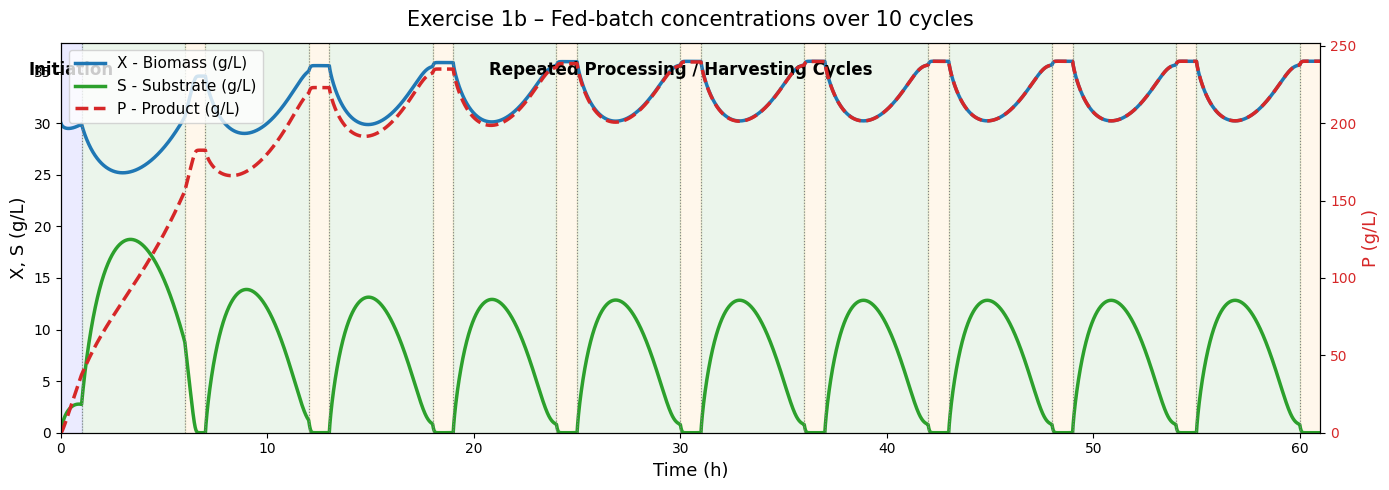

In [4]:
y = res_I[-1]

cycle_time = 6.0
n_cycles = 10

t_all_b = [t_I]
X_all_b = [X_I]
S_all_b = [S_I]
P_all_b = [P_I]

P_produced_10 = None
P_harvested_10 = None

for cycle in range(1, n_cycles + 1):

    t_start = 1.0 + (cycle - 1) * cycle_time

    
    t_proc = np.linspace(t_start, t_start + 5.0, 1000000)
    res_proc = odeint(odes_processing, y, t_proc)

    
    t_harv = np.linspace(t_start + 5.0, t_start + 6.0, 1000000)
    res_harv = odeint(odes_harvesting, res_proc[-1], t_harv)

    
    X_proc, S_proc, P_proc = to_conc(*res_proc.T)
    X_harv, S_harv, P_harv = to_conc(*res_harv.T)

    
    t_all_b.extend([t_proc, t_harv])
    X_all_b.extend([X_proc, X_harv])
    S_all_b.extend([S_proc, S_harv])
    P_all_b.extend([P_proc, P_harv])

    
    if cycle == 10:
        NxP, NsP, NpP, VP = res_proc.T
        XP = NxP / VP
        SP_conc = np.maximum(NsP / VP, 0)

        NxH, NsH, NpH, VH = res_harv.T
        XH = NxH / VH
        SH_conc = np.maximum(NsH / VH, 0)
        PH_conc = NpH / VH

        P_produced_proc = np.trapz((mu_net(SP_conc) / Yxp) * XP * VP, t_proc)
        P_produced_harv = np.trapz((mu_net(SH_conc) / Yxp) * XH * VH, t_harv)

        P_produced_10 = P_produced_proc + P_produced_harv
        P_harvested_10 = np.trapz(FH * PH_conc, t_harv)

   
    y = res_harv[-1]



t_all_b = np.concatenate(t_all_b)
X_all_b = np.concatenate(X_all_b)
S_all_b = np.concatenate(S_all_b)
P_all_b = np.concatenate(P_all_b)


net_rate = (P_produced_10 - P_harvested_10) / cycle_time


harvest_productivity = P_harvested_10 / cycle_time


print("Problem 1(b): 10-cycle results")
print("--------------------------------")
print(f"P produced in 10th cycle  = {P_produced_10:.4f} g")
print(f"P harvested in 10th cycle = {P_harvested_10:.4f} g")
print(f"Net accumulation rate     = {net_rate:.4f} g/h")
print(f"Harvest productivity      = {harvest_productivity:.4f} g/h")
print()
print("Final state after 10 cycles")
print(f"X = {X_all_b[-1]:.4f} g/L")
print(f"S = {S_all_b[-1]:.4f} g/L")
print(f"P = {P_all_b[-1]:.4f} g/L")



fig, ax1 = plt.subplots(figsize=(14, 5))

line1, = ax1.plot(t_all_b, X_all_b, color="#1f77b4", lw=2.5,
                  label="X - Biomass (g/L)")

line2, = ax1.plot(t_all_b, S_all_b, color="#2ca02c", lw=2.5,
                  label="S - Substrate (g/L)")

ax1.set_xlabel("Time (h)", fontsize=13)
ax1.set_ylabel("X, S (g/L)", fontsize=13)
ax1.set_xlim(0, 61)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()

line3, = ax2.plot(t_all_b, P_all_b, color="#d62728", lw=2.5,
                  ls="--", label="P - Product (g/L)")

ax2.set_ylabel("P (g/L)", fontsize=13, color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")
ax2.set_ylim(bottom=0)


ax1.axvspan(0, 1, alpha=0.08, color="blue")

for cycle in range(n_cycles):
    base = 1 + cycle * cycle_time
    ax1.axvspan(base, base + 5, alpha=0.08, color="green")
    ax1.axvspan(base + 5, base + 6, alpha=0.08, color="orange")
    ax1.axvline(base, color="grey", lw=0.8, ls=":")
    ax1.axvline(base + 5, color="grey", lw=0.8, ls=":")

y_text = ax1.get_ylim()[1] * 0.93

ax1.text(0.5, y_text, "Initiation",
         ha="center", va="center", fontsize=12, fontweight="bold")

ax1.text(30, y_text, "Repeated Processing / Harvesting Cycles",
         ha="center", va="center", fontsize=12, fontweight="bold")

lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc="upper left", fontsize=11)

plt.title("Exercise 1b – Fed-batch concentrations over 10 cycles",
          fontsize=15, pad=12)

plt.tight_layout()
plt.show()

# Problem 2

Exercise 2 optimization results
Optimal S_P = 110.114 g glucose/L
Maximum production rate = 137.599 g product/h

Production rates near the optimum:
S_P =   95.0 g/L -> production rate =  118.708 g/h
S_P =  100.0 g/L -> production rate =  124.960 g/h
S_P =  105.0 g/L -> production rate =  131.211 g/h
S_P =  108.0 g/L -> production rate =  134.962 g/h
S_P =  109.0 g/L -> production rate =  136.212 g/h
S_P =  110.0 g/L -> production rate =  137.462 g/h
S_P =  110.1 g/L -> production rate =  137.587 g/h
S_P =  111.0 g/L -> production rate =   43.573 g/h
S_P =  112.0 g/L -> production rate =   27.243 g/h
S_P =  115.0 g/L -> production rate =   13.609 g/h


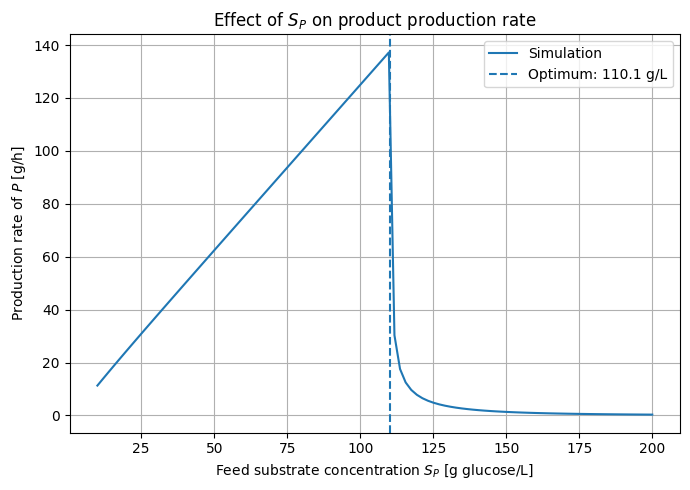

In [5]:
mu_max = 0.3
K_S = 0.8         
K_I = 100.0

Y_XS = 0.45
Y_XP = 0.15

S0 = 80.0
F_I = 0.2
F_P = 0.5
F_H = 2.5

t_initiation = 1.0 
t_processing = 5.0
t_harvesting = 1.0
n_cycles = 10

V0 = 0.85
X0 = 30.0
S_initial = 0.0 
P_initial = 0.0

def mu(S):
    """
    Specific growth rate with substrate inhibition.
    S is glucose concentration in g/L.
    """
    S = max(S, 0.0)
    return mu_max * S / (K_S + S + (S**2 / K_I))

def reactor_odes(t, y, phase, S_P):
    """
    State vector:
    y[0] = N_X = mass of cells, g
    y[1] = N_S = mass of substrate, g
    y[2] = N_P = mass of product, g
    y[3] = V   = reactor volume, L
    y[4] = H_P = cumulative harvested product, g
    y[5] = G_P = cumulative generated product, g
    """

    N_X, N_S, N_P, V, H_P, G_P = y

    V = max(V, 1e-12)

    X = N_X / V
    S = N_S / V
    P = N_P / V

    mu_val = mu(S)

    cell_growth = mu_val * N_X
    substrate_consumption = cell_growth / Y_XS
    product_generation = cell_growth / Y_XP

    if phase == "initiation":
        F_in = F_I
        S_in = S0
        F_out = 0.0

    elif phase == "processing":
        F_in = F_P
        S_in = S_P
        F_out = 0.0

    elif phase == "harvesting":
        F_in = 0.0
        S_in = 0.0
        F_out = F_H

    else:
        raise ValueError("Unknown phase")

    dN_Xdt = cell_growth - F_out * X
    dN_Sdt = F_in * S_in - substrate_consumption - F_out * S
    dN_Pdt = product_generation - F_out * P
    dVdt = F_in - F_out

    dH_Pdt = F_out * P

    dG_Pdt = product_generation

    return [dN_Xdt, dN_Sdt, dN_Pdt, dVdt, dH_Pdt, dG_Pdt]


def integrate_phase(y0, t0, duration, phase, S_P):
    """
    Integrates one phase of the fed-batch operation.
    """

    sol = solve_ivp(
        fun=lambda t, y: reactor_odes(t, y, phase, S_P),
        t_span=(t0, t0 + duration),
        y0=y0,
        method="BDF",
        rtol=1e-8,
        atol=1e-10
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    return sol


def simulate_process(S_P, save_profiles=False):
    """
    Simulates:
    - initiation phase
    - 10 processing/harvesting cycles

    Returns production rate during the 10th cycle.
    """

    N_X0 = X0 * V0
    N_S0 = S_initial * V0
    N_P0 = P_initial * V0

    y = np.array([N_X0, N_S0, N_P0, V0, 0.0, 0.0])
    t = 0.0

    all_t = []
    all_y = []

    cycle_results = []

    sol = integrate_phase(y, t, t_initiation, "initiation", S_P)
    y = sol.y[:, -1]
    t = sol.t[-1]

    if save_profiles:
        all_t.append(sol.t)
        all_y.append(sol.y)

    for cycle in range(1, n_cycles + 1):

        H_start = y[4]
        G_start = y[5]
        NP_start = y[2]

        sol = integrate_phase(y, t, t_processing, "processing", S_P)
        y = sol.y[:, -1]
        t = sol.t[-1]

        if save_profiles:
            all_t.append(sol.t)
            all_y.append(sol.y)

        sol = integrate_phase(y, t, t_harvesting, "harvesting", S_P)
        y = sol.y[:, -1]
        t = sol.t[-1]

        if save_profiles:
            all_t.append(sol.t)
            all_y.append(sol.y)

        H_cycle = y[4] - H_start
        G_cycle = y[5] - G_start
        NP_change = y[2] - NP_start

        cycle_results.append({
            "cycle": cycle,
            "harvested_product_g": H_cycle,
            "generated_product_g": G_cycle,
            "product_mass_change_g": NP_change
        })

    cycle_time = t_processing + t_harvesting
    harvested_10th_cycle = cycle_results[-1]["harvested_product_g"]
    production_rate = harvested_10th_cycle / cycle_time

    if save_profiles:
        all_t = np.concatenate(all_t)
        all_y = np.concatenate(all_y, axis=1)
        return production_rate, cycle_results, all_t, all_y

    return production_rate


def objective(S_P):
    """
    Negative production rate because scipy minimizes.
    """
    return -simulate_process(S_P)


if __name__ == "__main__":

    S_P_values = np.linspace(10, 200, 100)
    production_rates = []

    for S_P in S_P_values:
        rate = simulate_process(S_P)
        production_rates.append(rate)

    production_rates = np.array(production_rates)

    result = minimize_scalar(
        objective,
        bounds=(10, 200),
        method="bounded",
        options={"xatol": 1e-4}
    )

    S_P_opt = result.x
    max_rate = -result.fun

    print("====================================")
    print("Exercise 2 optimization results")
    print("====================================")
    print(f"Optimal S_P = {S_P_opt:.3f} g glucose/L")
    print(f"Maximum production rate = {max_rate:.3f} g product/h")

    print("\nProduction rates near the optimum:")
    for S_test in [95, 100, 105, 108, 109, 110, 110.1, 111, 112, 115]:
        rate = simulate_process(S_test)
        print(f"S_P = {S_test:6.1f} g/L -> production rate = {rate:8.3f} g/h")

    plt.figure(figsize=(7, 5))
    plt.plot(S_P_values, production_rates, label="Simulation")
    plt.axvline(S_P_opt, linestyle="--", label=f"Optimum: {S_P_opt:.1f} g/L")
    plt.xlabel(r"Feed substrate concentration $S_P$ [g glucose/L]")
    plt.ylabel(r"Production rate of $P$ [g/h]")
    plt.title(r"Effect of $S_P$ on product production rate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("exercise2_production_rate_vs_SP.png", dpi=300)
    plt.show()